In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# Exercício 1

1. Gere uma amostra de tamanho $K$ de uma variável com distribuição binomial negativa com parâmetros $p$ $r$ utilizando os três métodos vistos em sala: via Bernoullis, via soma de geométricas, via recursão.
2. Compare com uma amostra gerada pelo numpy usando histogramas.
3. Compare o tempo dos três métodos como visto nos labs anteriores.



1.1.1 - Recursão

(array([105., 303., 251., 222.,  71.,  37.,   7.,   2.,   1.,   1.]),
 array([ 5. ,  9.6, 14.2, 18.8, 23.4, 28. , 32.6, 37.2, 41.8, 46.4, 51. ]),
 <BarContainer object of 10 artists>)

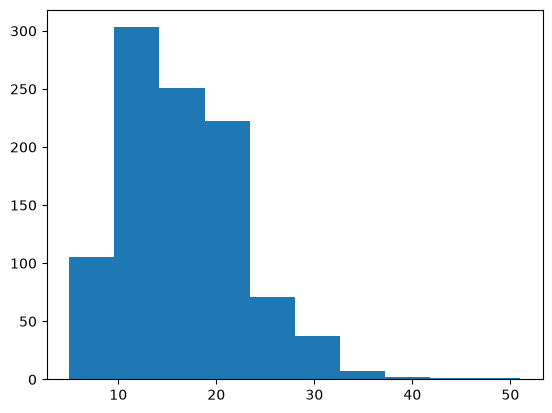

In [2]:
K = 1000
r = 5
p = 0.3
amostra_binneg = []
for _ in range(K):
    U = np.random.uniform()
    pi = p**r
    n = r
    F = pi
    
    while U > F:
        pi *= (1-p)*n/(n-r+1)
        n += 1 
        F += pi
    amostra_binneg.append(n)

plt.hist(amostra_binneg)


1.1.2 - Por Bernoullis

(array([ 59., 216., 285., 150., 162.,  65.,  26.,  22.,  10.,   5.]),
 array([ 5. ,  8.7, 12.4, 16.1, 19.8, 23.5, 27.2, 30.9, 34.6, 38.3, 42. ]),
 <BarContainer object of 10 artists>)

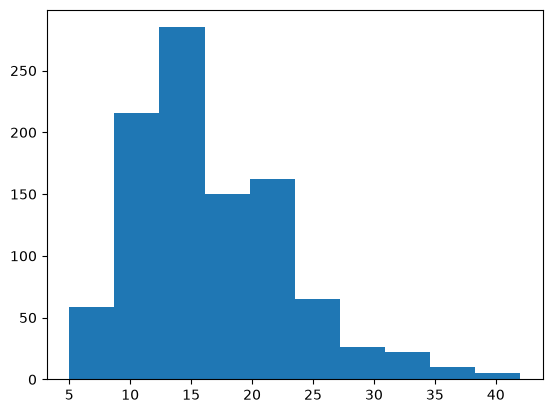

In [3]:
r = 5
p = 0.3
amostra = []
for _ in range(K):
    n = 0
    s = 0
    while s < r:
        B = np.random.uniform() < p
        n += 1 
        s += B
    amostra.append(n)

plt.hist(amostra)

1.1.3 - Por Geométricas

(array([ 56., 233., 201., 237., 113., 105.,  34.,  12.,   7.,   2.]),
 array([ 5. ,  8.6, 12.2, 15.8, 19.4, 23. , 26.6, 30.2, 33.8, 37.4, 41. ]),
 <BarContainer object of 10 artists>)

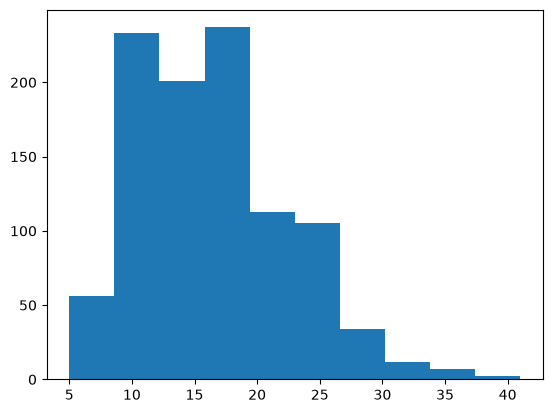

In [13]:
r = 5
p = 0.3
binomial_negativa = []
for _ in range(K):
    geometricas = []
    soma = 0
    for _ in range(r):
        U = np.random.uniform()
        x = np.floor(np.log(1-U)/np.log(1-p)) + 1
        geometricas.append(x)
        soma = sum(geometricas)
    binomial_negativa.append(soma)

plt.hist(binomial_negativa)
        


In [14]:
media_por_recursao = np.mean(amostra_binneg)
media_por_bernoullis = np.mean(amostra)
media_por_geometricas = np.mean(binomial_negativa)

print(f' A média pelo método de recursão foi: {media_por_recursao}')
print(f' A média pelo método por bernoullis foi: {media_por_bernoullis}')
print(f' A média pelo método por geométricas foi: {media_por_geometricas}')
print(f' A média gerada pelo numpy foi de {np.mean(np.random.negative_binomial(r,p, size=K))+r}')

 A média pelo método de recursão foi: 16.561
 A média pelo método por bernoullis foi: 16.642
 A média pelo método por geométricas foi: 16.429
 A média gerada pelo numpy foi de 16.411


1.2

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(12,5), sharey=True)
ax[0] = 

1.3

In [15]:
ps = np.linspace(0.05,0.9)
tempo_bernoulli = []
for p in ps:
    inicio = time.time()
    


# Exercício 2

1.  Gere uma amostra de tamanho $K$ de uma variável aleatória com distribuição hipergeométrica com parâmetros $M,N,n$ utilizando o método de embaralhamento de Fisher–Yates.
2.  No método de Fisher-Yates, no passo (a), a gente amostra um ponto para troca entre $i$ e $N$. Pense em qual seria o problema caso a gente sempre amostrasse entre $1$ e $N$. Compare o resultado final usando essas duas versões e uma amostra gerada pelo numpy.

# Exercício 3

É intuitivo esperar que, quando o tamanho total da população $M+N$ cresce muito em relação ao tamanho da amostra $n$, o fato de a amostragem ser feita sem reposição passe a ter pouca importância, pois retirar um elemento altera muito pouco a composição da população restante. Nesse caso, cada retirada deve se comportar aproximadamente como um ensaio de Bernoulli independente, com probabilidade de sucesso

$$
p=\frac{N}{M+N}.
$$

Assim, esperamos que a distribuição hipergeométrica com parâmetros $M,N,n$ se aproxime de uma distribuição binomial com parâmetros $n$ e $p$.

Compare numericamente essas duas distribuições para valores crescentes de $M$ e $N$, mantendo aproximadamente constante a proporção

$$
\frac{N}{M+N}\to p,
$$

e mantendo $n$ fixo. Verifique, por meio de simulações, se a aproximação pela distribuição binomial melhora à medida que $M+N$ aumenta.
